# Fine-tuning YOLOv8 sur CAPTCHAs réels

**Objectif**: Fine-tuner le modèle baseline sur les CAPTCHAs annotés depuis le site cible.

## Pré-requis
- Modèle baseline `best.pt` dans `models/weights/`
- Dataset annoté dans `datasets/captcha_target_v1_yolo/`

## Différences avec le baseline
| Paramètre | Baseline | Fine-tuning |
|-----------|----------|-------------|
| Modèle initial | yolov8s.pt | **best.pt (baseline)** |
| Epochs | 120 | **50** |
| Learning rate | 0.01 | **0.001** (10x plus petit) |
| Patience | 20 | **10** |

---
# 1. Setup

In [1]:
# ==================================================
# 1.1 Vérifier GPU
# ==================================================
!nvidia-smi

Fri Jan 30 11:13:07 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.54.15              Driver Version: 550.54.15      CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA L4                      Off |   00000000:00:03.0 Off |                    0 |
| N/A   40C    P8             12W /   72W |       0MiB /  23034MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [25]:
# ==================================================
# 1.2 Installations
# ==================================================
!pip -q install -U ultralytics roboflow
!yolo settings sync=False

✅ Updated 'sync=False'
JSONDict("/root/.config/Ultralytics/settings.json"):
{
  "settings_version": "0.0.6",
  "datasets_dir": "/content/datasets",
  "weights_dir": "weights",
  "runs_dir": "runs",
  "uuid": "569f3ba64b326db489132663f79cd37279811de477381b83ac131e6cdd129cbb",
  "sync": false,
  "api_key": "",
  "openai_api_key": "",
  "clearml": true,
  "comet": true,
  "dvc": true,
  "hub": true,
  "mlflow": true,
  "neptune": true,
  "raytune": true,
  "tensorboard": false,
  "wandb": false,
  "vscode_msg": true,
  "openvino_msg": true
}
💡 Learn more about Ultralytics Settings at https://docs.ultralytics.com/quickstart/#ultralytics-settings


In [26]:
# ==================================================
# 1.3 Imports
# ==================================================
import os
import torch
import random
from pathlib import Path
from collections import Counter

import yaml
import numpy as np
import matplotlib.pyplot as plt

from ultralytics import YOLO
import ultralytics

# Reproductibilité
random.seed(42)
np.random.seed(42)

ultralytics.checks()

Ultralytics 8.4.9 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (NVIDIA L4, 22693MiB)
Setup complete ✅ (12 CPUs, 53.0 GB RAM, 39.0/112.6 GB disk)


In [ ]:
# ==================================================
# 1.4 Configuration
# ==================================================
from dotenv import load_dotenv
load_dotenv()

# ----- Auto-détection environnement -----
# COLAB_RELEASE_TAG n'existe que sur une vraie VM Colab
COLAB = "COLAB_RELEASE_TAG" in os.environ

if COLAB:
    from google.colab import drive
    drive.mount("/content/drive")
    PROJECT_ROOT = Path("/content/drive/MyDrive/Colab Notebooks/captcha_yolo_project")
    MODELS_DIR   = PROJECT_ROOT / "models"
else:
    PROJECT_ROOT = Path.cwd()
    MODELS_DIR   = PROJECT_ROOT / "models" / "weights"

RUNS_DIR     = PROJECT_ROOT / "runs"
DATASETS_DIR = PROJECT_ROOT / "datasets"

# ----- Modèle baseline -----
BASELINE_MODEL = MODELS_DIR / "best.pt"

# --- Sortie fine-tuning ---
FT_PROJECT_DIR = RUNS_DIR / "fine_tune"
FT_NAME = "ft_v1"
FINETUNED_MODEL_OUT = MODELS_DIR / f"best_ft_{FT_NAME}.pt"

# ----- Device (auto-détection) -----
DEVICE = 0 if torch.cuda.is_available() else "cpu"

# ----- Roboflow (Colab : téléchargement dataset) -----
ROBOFLOW_API_KEY   = os.getenv("ROBOFLOW_API_KEY")
ROBOFLOW_WORKSPACE = "hana-zkkrt"
ROBOFLOW_PROJECT   = "captcha-target-v1"
ROBOFLOW_VERSION   = 4

# ----- Fine-tuning (paramètres RÉDUITS) -----
EPOCHS = 100
PATIENCE = 15
LR0 = 0.001
LRF = 0.01
WARMUP_EPOCHS = 3
IMGSZ = 512
BATCH_SIZE = 16

# ----- Inference -----
CONF_THRESHOLD = 0.25
IOU_THRESHOLD = 0.6

# --- Création dossiers ---
MODELS_DIR.mkdir(parents=True, exist_ok=True)
RUNS_DIR.mkdir(parents=True, exist_ok=True)
DATASETS_DIR.mkdir(parents=True, exist_ok=True)
FT_PROJECT_DIR.mkdir(parents=True, exist_ok=True)

ENV = "COLAB (GPU)" if COLAB else f"LOCAL ({'GPU' if DEVICE == 0 else 'CPU'})"
print(f"\n Configuration fine-tuning chargée ({ENV})")
print(f"  - Device  : {DEVICE}")
print(f"  - Baseline: {BASELINE_MODEL}")
print(f"  - Output  : {FINETUNED_MODEL_OUT}")
print(f"  - Epochs  : {EPOCHS} (patience={PATIENCE}) | imgsz={IMGSZ} | batch={BATCH_SIZE}")
print(f"  - lr0={LR0}, lrf={LRF}, warmup_epochs={WARMUP_EPOCHS}")

In [28]:
# ==================================================
# 1.5 Vérifier le modèle baseline
# ==================================================
if BASELINE_MODEL.exists():
    print(f"Modèle baseline présent: {BASELINE_MODEL}")
else:
    raise FileNotFoundError(f"Modèle baseline introuvable: {BASELINE_MODEL}")

Modèle baseline présent: /content/drive/MyDrive/Colab Notebooks/captcha_yolo_project/models/best.pt


---
# 2. Dataset

In [29]:
# ==================================================
# 2.1 Télécharger / vérifier le dataset
# ==================================================
if COLAB:
    %cd {DATASETS_DIR}
    from roboflow import Roboflow
    rf = Roboflow(api_key=ROBOFLOW_API_KEY)
    project = rf.workspace(ROBOFLOW_WORKSPACE).project(ROBOFLOW_PROJECT)
    dataset = project.version(ROBOFLOW_VERSION).download("yolov8")
    DATASET_DIR = Path(dataset.location)
else:
    DATASET_DIR = DATASETS_DIR / "captcha_target_v1_yolo"
    if not DATASET_DIR.exists():
        raise FileNotFoundError(f"Dataset introuvable: {DATASET_DIR}")

DATA_YAML = DATASET_DIR / "data.yaml"
if not DATA_YAML.exists():
    raise FileNotFoundError(f"data.yaml introuvable: {DATA_YAML}")

print(f"\nDataset : {DATASET_DIR}")
print(f"data.yaml: {DATA_YAML}")

/content/drive/MyDrive/Colab Notebooks/captcha_yolo_project/datasets
loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to captcha-target-v1-4 in yolov8:: 100%|██████████| 622/622 [00:03<00:00, 205.27it/s]


Dataset : /content/drive/MyDrive/Colab Notebooks/captcha_yolo_project/datasets/captcha-target-v1-4
data.yaml: /content/drive/MyDrive/Colab Notebooks/captcha_yolo_project/datasets/captcha-target-v1-4/data.yaml


In [30]:
# ==================================================
# 2.2 Vérifier le dataset
# ==================================================
with open(DATA_YAML, "r") as f:
    data_yaml = yaml.safe_load(f)

CLASS_NAMES = data_yaml["names"]
NUM_CLASSES = data_yaml["nc"]

print(f"Classes: {NUM_CLASSES}")
print(f"Premiers: {CLASS_NAMES[:10]}")
print(f"Derniers: {CLASS_NAMES[-10:]}")

print("\nSplit     | Images | Labels | OK")
print("-" * 40)

for split in ["train", "valid", "test"]:
    img_dir = DATASET_DIR / split / "images"
    lab_dir = DATASET_DIR / split / "labels"

    if img_dir.exists():
        n_imgs = len(list(img_dir.glob("*")))
        n_labs = len(list(lab_dir.glob("*.txt"))) if lab_dir.exists() else 0
        status = "OK" if n_imgs == n_labs and n_imgs > 0 else "ERREUR"
        print(f"{split:9} | {n_imgs:6} | {n_labs:6} | {status}")
    else:
        print(f"{split:9} | -- pas de données --")

Classes: 62
Premiers: ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9']
Derniers: ['q', 'r', 's', 't', 'u', 'v', 'w', 'x', 'y', 'z']

Split     | Images | Labels | OK
----------------------------------------
train     |    230 |    230 | OK
valid     |     50 |     50 | OK
test      |     25 |     25 | OK


---
# 3. Fine-tuning

In [31]:
# ==================================================
# 3.1 Charger le modèle BASELINE
# ==================================================
model = YOLO(str(BASELINE_MODEL))

print(f"✓ Modèle baseline chargé: {BASELINE_MODEL}")
print(f"  - Ce modèle a déjà appris à détecter les caractères")
print(f"  - Le fine-tuning va l'adapter aux CAPTCHAs du site cible")

✓ Modèle baseline chargé: /content/drive/MyDrive/Colab Notebooks/captcha_yolo_project/models/best.pt
  - Ce modèle a déjà appris à détecter les caractères
  - Le fine-tuning va l'adapter aux CAPTCHAs du site cible


In [32]:
# ==================================================
# 3.2 Lancer le fine-tuning
# ==================================================
results = model.train(
    data=str(DATA_YAML),

    # === PARAMÈTRES RÉDUITS (transfer learning) ===
    epochs=EPOCHS,
    patience=PATIENCE,

    # === LEARNING RATE RÉDUIT (crucial!) ===
    lr0=LR0,
    lrf=LRF,
    warmup_epochs=WARMUP_EPOCHS,

    # === Image et batch ===
    imgsz=IMGSZ,
    batch=BATCH_SIZE,
    device=DEVICE,

    # === Augmentations (mêmes que baseline) ===
    hsv_h=0.015,
    hsv_s=0.7,
    hsv_v=0.4,
    degrees=15,
    translate=0.1,
    scale=0.4,
    shear=5,
    perspective=0.0005,

    # === IMPORTANT: Désactivés pour CAPTCHAs ===
    mosaic=0.0,
    mixup=0.0,

    project=str(FT_PROJECT_DIR),
    name=FT_NAME,
    plots=False,

    # === Optionnel: Geler les premières couches ===
    freeze=10,  # Décommenter si overfitting (peu de données)
)

TRAIN_DIR = Path(results.save_dir)
print(f"\n" + "="*50)
print(f"FINE-TUNING TERMINÉ !")
print(f"="*50)
print(f"Dossier: {TRAIN_DIR}")
print(f"Meilleur modèle: {TRAIN_DIR / 'weights' / 'best.pt'}")

Ultralytics 8.4.9 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (NVIDIA L4, 22693MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/MyDrive/Colab Notebooks/captcha_yolo_project/datasets/captcha-target-v1-4/data.yaml, degrees=15, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=10, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=512, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=/content/drive/MyDrive/Colab Notebooks/captcha_yolo_project/models/best.pt, momentum=0.937, mosaic=0.0, multi_sc

In [33]:
# ==================================================
# 3.3 Sauvegarder le modèle fine-tuné
# ==================================================
import shutil

best_model_src = TRAIN_DIR / "weights" / "best.pt"

if best_model_src.exists():
    shutil.copy(best_model_src, FINETUNED_MODEL_OUT)
    print(f"Modèle fine-tuné sauvegardé: {FINETUNED_MODEL_OUT}")
else:
    print(f"Modèle non trouvé: {best_model_src}")

Modèle fine-tuné sauvegardé: /content/drive/MyDrive/Colab Notebooks/captcha_yolo_project/models/best_ft_ft_v1.pt


---
# 4. Évaluation

In [34]:
# ==================================================
# 4.1 Charger le modèle fine-tuné
# ==================================================
model_finetuned = YOLO(str(FINETUNED_MODEL_OUT))
print(f"Modèle fine-tuné chargé: {FINETUNED_MODEL_OUT}")

Modèle fine-tuné chargé: /content/drive/MyDrive/Colab Notebooks/captcha_yolo_project/models/best_ft_ft_v1.pt


In [35]:
# ==================================================
# 4.2 Fonctions de décodage (mêmes que baseline)
# ==================================================

def iou_xyxy(box_a, box_b):
    ax1, ay1, ax2, ay2 = box_a
    bx1, by1, bx2, by2 = box_b
    ix1, iy1 = max(ax1, bx1), max(ay1, by1)
    ix2, iy2 = min(ax2, bx2), min(ay2, by2)
    inter = max(0, ix2 - ix1) * max(0, iy2 - iy1)
    area_a = (ax2 - ax1) * (ay2 - ay1)
    area_b = (bx2 - bx1) * (by2 - by1)
    union = area_a + area_b - inter
    return inter / union if union > 0 else 0.0


def decode_prediction(result, names, conf_threshold=0.25, iou_threshold=0.6):
    boxes = result.boxes
    if boxes is None or len(boxes) == 0:
        return "", []

    dets = []
    for b in boxes:
        conf = float(b.conf)
        if conf < conf_threshold:
            continue
        cls_id = int(b.cls)
        x1, y1, x2, y2 = map(float, b.xyxy[0])
        dets.append({
            "box": [x1, y1, x2, y2],
            "conf": conf,
            "char": names[cls_id],
            "x_center": (x1 + x2) / 2.0
        })

    if not dets:
        return "", []

    # NMS
    dets.sort(key=lambda d: d["conf"], reverse=True)
    kept = []
    for d in dets:
        if all(iou_xyxy(d["box"], k["box"]) < iou_threshold for k in kept):
            kept.append(d)

    # Tri gauche -> droite
    kept.sort(key=lambda d: d["x_center"])
    text = "".join(d["char"] for d in kept)

    return text, kept


def decode_ground_truth(label_path, names):
    if not label_path.exists():
        return ""
    items = []
    for line in label_path.read_text().strip().splitlines():
        parts = line.split()
        if len(parts) >= 2:
            cls_id = int(float(parts[0]))
            x_center = float(parts[1])
            items.append((x_center, names[cls_id]))
    items.sort(key=lambda t: t[0])
    return "".join(ch for _, ch in items)


def levenshtein(a, b):
    if a == b: return 0
    if len(a) == 0: return len(b)
    if len(b) == 0: return len(a)
    dp = list(range(len(b) + 1))
    for i in range(1, len(a) + 1):
        prev = dp[0]
        dp[0] = i
        for j in range(1, len(b) + 1):
            temp = dp[j]
            cost = 0 if a[i-1] == b[j-1] else 1
            dp[j] = min(dp[j] + 1, dp[j-1] + 1, prev + cost)
            prev = temp
    return dp[-1]


def cer(pred, gt):
    if len(gt) == 0:
        return 0.0 if len(pred) == 0 else 1.0
    return levenshtein(pred, gt) / len(gt)


print("✓ Fonctions de décodage chargées")

✓ Fonctions de décodage chargées


In [36]:
# ==================================================
# 4.3 Évaluation sur le test set
# ==================================================
test_img_dir = DATASET_DIR / "test" / "images"
test_lab_dir = DATASET_DIR / "test" / "labels"

if not test_img_dir.exists():
    # Si pas de test set, utiliser valid
    print("Pas de test set, utilisation du valid set")
    test_img_dir = DATASET_DIR / "valid" / "images"
    test_lab_dir = DATASET_DIR / "valid" / "labels"

all_images = list(test_img_dir.glob("*"))
print(f"Évaluation sur {len(all_images)} images...\n")

exact_match = 0
cers = []
errors = []

for img_path in all_images:
    # Ground truth
    label_path = test_lab_dir / f"{img_path.stem}.txt"
    gt = decode_ground_truth(label_path, CLASS_NAMES)

    # Prédiction
    res = model_finetuned.predict(str(img_path), conf=CONF_THRESHOLD, imgsz=IMGSZ, device=DEVICE, verbose=False)[0]
    pred, _ = decode_prediction(res, CLASS_NAMES, CONF_THRESHOLD, IOU_THRESHOLD)

    # Métriques
    if pred == gt:
        exact_match += 1
    else:
        c = cer(pred, gt)
        errors.append((img_path.name, gt, pred, c))
    cers.append(cer(pred, gt))

cers = np.array(cers)

print("=" * 50)
print("RÉSULTATS FINE-TUNING")
print("=" * 50)
print(f"Exact Match Accuracy : {exact_match/len(all_images):.3f} ({exact_match}/{len(all_images)})")
print(f"CER moyen            : {cers.mean():.3f}")
print(f"CER médian           : {np.median(cers):.3f}")
print(f"CER P90              : {np.percentile(cers, 90):.3f}")

Évaluation sur 25 images...

RÉSULTATS FINE-TUNING
Exact Match Accuracy : 0.840 (21/25)
CER moyen            : 0.032
CER médian           : 0.000
CER P90              : 0.200


In [37]:
# ==================================================
# 4.4 Comparaison Baseline vs Fine-tuned
# ==================================================
print("\n" + "=" * 50)
print("COMPARAISON")
print("=" * 50)
print(f"{'Métrique':<25} | {'Baseline':<12} | {'Fine-tuned':<12}")
print("-" * 55)
print(f"{'Dataset':<25} | {'Roboflow':<12} | {'CAPTCHAs réels':<12}")
print(f"{'Exact Match (test)':<25} | {'86.5%':<12} | {exact_match/len(all_images)*100:.1f}%")
print(f"{'CER moyen':<25} | {'2.7%':<12} | {cers.mean()*100:.1f}%")
print("\n⚠️  Note: Les datasets sont différents, comparaison indicative")


COMPARAISON
Métrique                  | Baseline     | Fine-tuned  
-------------------------------------------------------
Dataset                   | Roboflow     | CAPTCHAs réels
Exact Match (test)        | 86.5%        | 84.0%
CER moyen                 | 2.7%         | 3.2%

⚠️  Note: Les datasets sont différents, comparaison indicative


Top erreurs:
  captcha_0078_png.rf.ca788e66ec: GT='cjZRN' | Pred='jZRN' | CER=0.20
  captcha_0118_png.rf.53c163c051: GT='ebHCP' | Pred='edHCP' | CER=0.20
  captcha_0147_png.rf.8056cbea1d: GT='HtTd3' | Pred='HtTh3' | CER=0.20
  captcha_0177_png.rf.0f3733009c: GT='YB4TA' | Pred='Y4TA' | CER=0.20


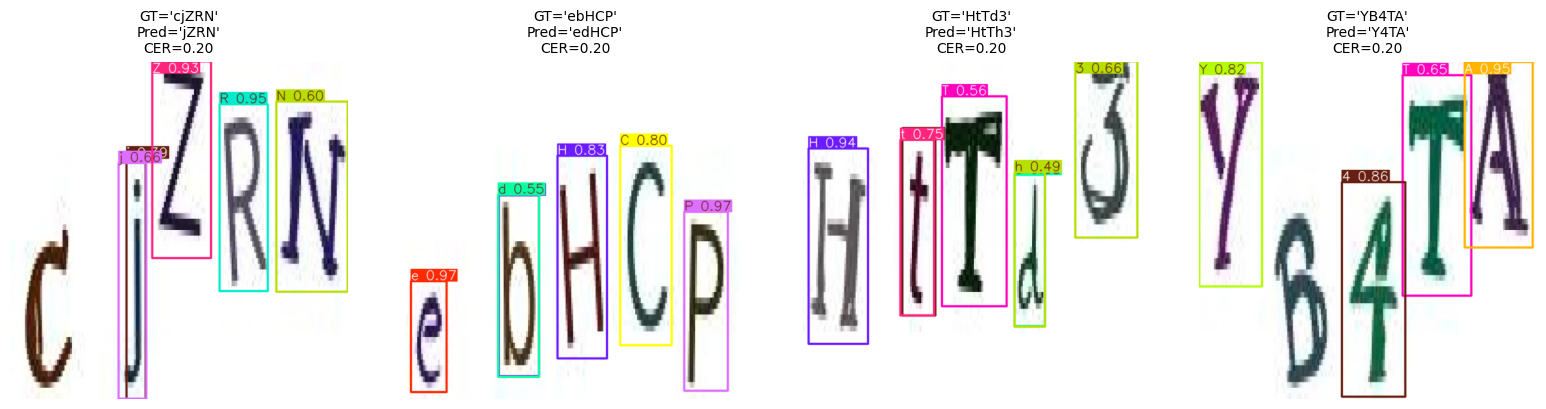

In [38]:
# ==================================================
# 4.5 Visualiser quelques erreurs (si il y en a)
# ==================================================
if errors:
    errors_sorted = sorted(errors, key=lambda x: x[3], reverse=True)

    print("Top erreurs:")
    for name, gt, pred, c in errors_sorted[:5]:
        print(f"  {name[:30]}: GT='{gt}' | Pred='{pred}' | CER={c:.2f}")

    # Afficher les 4 pires
    n_show = min(4, len(errors_sorted))
    fig, axes = plt.subplots(1, n_show, figsize=(4*n_show, 4))
    if n_show == 1:
        axes = [axes]

    for ax, (name, gt, pred, c) in zip(axes, errors_sorted[:n_show]):
        img_file = test_img_dir / name
        res = model_finetuned.predict(str(img_file), conf=CONF_THRESHOLD, imgsz=IMGSZ, device=DEVICE, verbose=False)[0]
        ax.imshow(res.plot())
        ax.set_title(f"GT='{gt}'\nPred='{pred}'\nCER={c:.2f}", fontsize=10)
        ax.axis("off")

    plt.tight_layout()
    plt.show()
else:
    print("Aucune erreur ! 100% Exact Match !")

Image: captcha_0072_png.rf.c2063c646569817789e1373b623879d5.jpg
GT:    'mMT7L'
Pred:  'mMT7L'
Match: OUI


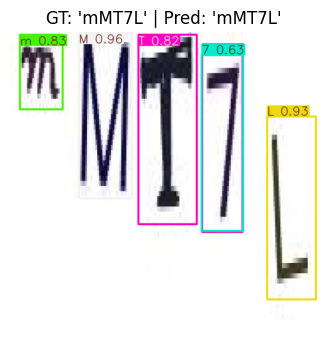

In [39]:
# ==================================================
# 4.6 Test sur une image aléatoire
# ==================================================
img_path = random.choice(all_images)
label_path = test_lab_dir / f"{img_path.stem}.txt"

gt = decode_ground_truth(label_path, CLASS_NAMES)
res = model_finetuned.predict(str(img_path), conf=CONF_THRESHOLD, imgsz=IMGSZ, device=DEVICE, verbose=False)[0]
pred, dets = decode_prediction(res, CLASS_NAMES, CONF_THRESHOLD, IOU_THRESHOLD)

print(f"Image: {img_path.name}")
print(f"GT:    '{gt}'")
print(f"Pred:  '{pred}'")
print(f"Match: {'OUI' if pred == gt else 'NON'}")

plt.figure(figsize=(12, 4))
plt.imshow(res.plot())
plt.title(f"GT: '{gt}' | Pred: '{pred}'")
plt.axis("off")
plt.show()

---
# 5. Résumé 

## Modèles disponibles
| Modèle | Chemin | Usage |
|--------|--------|-------|
| Baseline | `models/weights/best.pt` | CAPTCHAs génériques |
| Fine-tuné | `models/weights/best_ft_ft_v1.pt` | CAPTCHAs du site cible |
